<a href="https://colab.research.google.com/github/nikhilgupta-dev-bit/AI_Fitness_Tracer/blob/main/AI_job_market_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
df = pd.read_csv('clean_dataset.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850 entries, 0 to 1849
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event_id                 1850 non-null   object 
 1   company                  1850 non-null   object 
 2   industry                 1850 non-null   object 
 3   hq_country               1850 non-null   object 
 4   hq_city                  1850 non-null   object 
 5   continent                1850 non-null   object 
 6   founded_year             1850 non-null   int64  
 7   company_size_est         1850 non-null   int64  
 8   company_status           1850 non-null   object 
 9   date_announced           1850 non-null   object 
 10  year                     1850 non-null   int64  
 11  month                    1850 non-null   int64  
 12  quarter                  1850 non-null   object 
 13  number_laid_off          1850 non-null   int64  
 14  percentage_of_workforce 

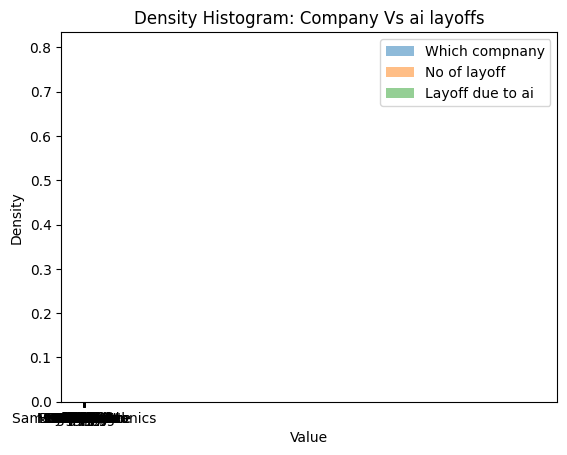

In [14]:
import matplotlib.pyplot as plt

plt.figure()

# Plot histograms with density normalization and transparency
plt.hist(df["company"].dropna(), bins=30, density=True, alpha=0.5, label="Which compnany")
plt.hist(df["number_laid_off"].dropna(), bins=30, density=True, alpha=0.5, label="No of layoff")
# Fix: Convert the boolean column 'is_ai_related_layoff' to integers (0s and 1s) for histogram plotting.
# Using bins=[0, 1, 2] will create two bins: one for 0 (False) and one for 1 (True).
plt.hist(df["is_ai_related_layoff"].astype(int).dropna(), bins=[0, 1, 2], density=True, alpha=0.5, label="Layoff due to ai")

# Some labels and legend
plt.title("Density Histogram: Company Vs ai layoffs")
# Changed labels to be more general as disparate data types are plotted together.
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

### Distribution of Layoffs by Company

Let's visualize the companies with the highest number of layoffs to understand which companies have been most affected. A bar chart is suitable for this categorical data.

/tmp/ipykernel_2322/561468051.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.index, y=top_companies.values, palette='viridis')


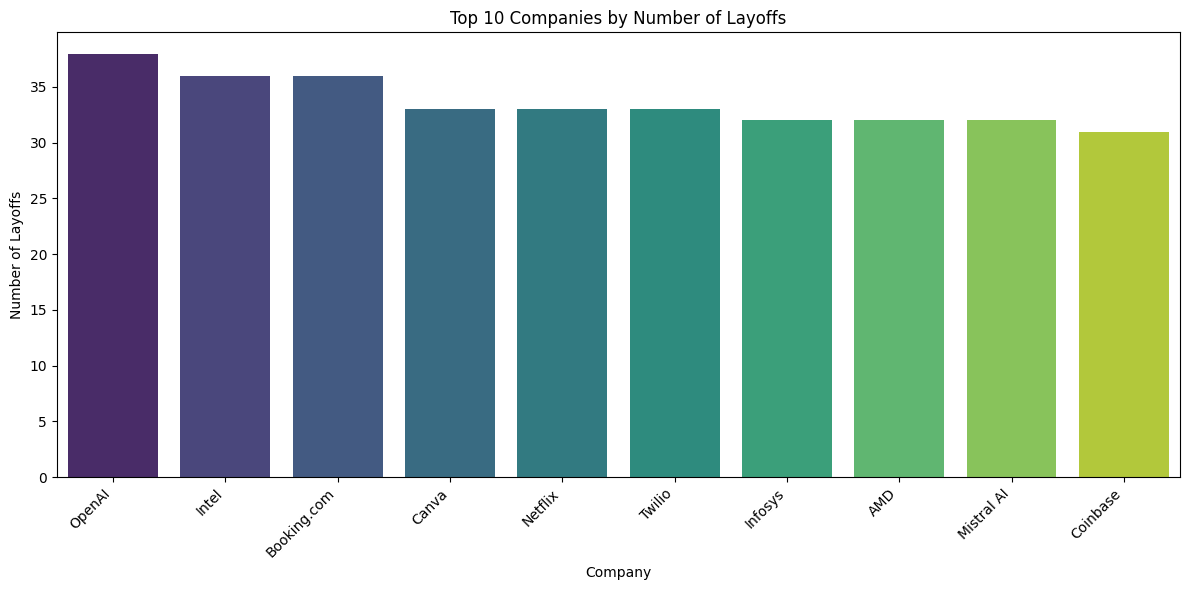

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 companies by number of layoffs
top_companies = df['company'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_companies.index, y=top_companies.values, palette='viridis')
plt.title('Top 10 Companies by Number of Layoffs')
plt.xlabel('Company')
plt.ylabel('Number of Layoffs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

### Distribution of Number Laid Off

Now, let's look at the distribution of the actual number of employees laid off in each event. A histogram is appropriate for this numerical data.

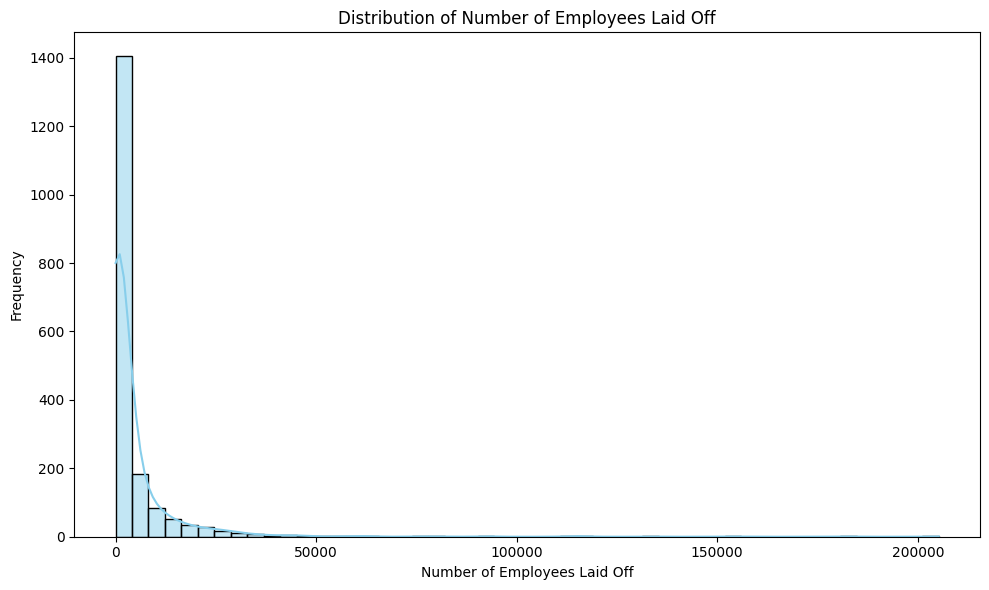

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['number_laid_off'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribution of Number of Employees Laid Off')
plt.xlabel('Number of Employees Laid Off')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### AI-Related Layoffs Analysis

Finally, let's clearly visualize the proportion of layoffs that are considered AI-related versus non-AI-related. A simple bar chart showing counts will be effective here.

/tmp/ipykernel_2322/797229148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_ai_related_layoff', data=df, palette='coolwarm')


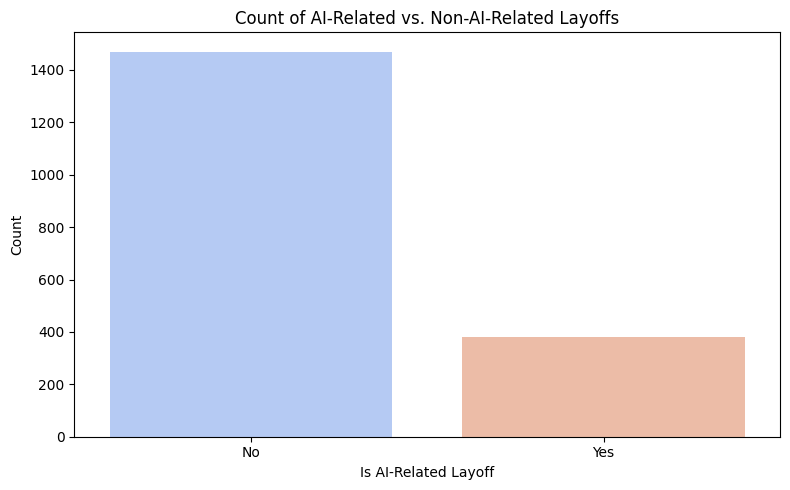

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_ai_related_layoff', data=df, palette='coolwarm')
plt.title('Count of AI-Related vs. Non-AI-Related Layoffs')
plt.xlabel('Is AI-Related Layoff')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target variable (y) and features (X)
y = df['is_ai_related_layoff']

# Drop columns that are not suitable for direct use as features or are redundant
# 'event_id', 'date_announced', 'source', 'severance_info' are dropped.
# 'is_ai_related_layoff' is the target variable (y) so it's dropped from X.
# 'percentage_of_workforce' is highly correlated with 'number_laid_off' and one is sufficient.

X = df.drop(columns=[
    'event_id', 'date_announced', 'source', 'severance_info',
    'is_ai_related_layoff', 'percentage_of_workforce'
])

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Features:", list(categorical_features))
print("Numerical Features:", list(numerical_features))

Categorical Features: ['company', 'industry', 'hq_country', 'hq_city', 'continent', 'company_status', 'quarter', 'departments_affected', 'primary_reason', 'impact_scope']
Numerical Features: ['founded_year', 'company_size_est', 'year', 'month', 'number_laid_off']


### 3. Building and Training the Model

We will use a `RandomForestClassifier` inside a `Pipeline`. The pipeline ensures that the preprocessing steps (like encoding the categorical features) are applied consistently to both the training and testing data.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define the preprocessing for the pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create the pipeline with a Random Forest Classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00       294
        True       1.00      1.00      1.00        76

    accuracy                           1.00       370
   macro avg       1.00      1.00      1.00       370
weighted avg       1.00      1.00      1.00       370



### 4. Investigating Potential Data Leakage

To understand why the model achieved 100% accuracy, let's look at the feature importance. If one feature is doing all the work, it might be a sign of leakage.

In [21]:
import pandas as pd
import numpy as np

# Get feature names from the one-hot encoder
ohe_feature_names = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numerical_features, ohe_feature_names])

# Get importances
importances = model_pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})

# Display top 10 most important features
display(feature_importance_df.sort_values(by='importance', ascending=False).head(10))

,feature,importance
1167,primary_reason_AI Automation Replacing Roles,0.183465
1182,primary_reason_Shift to AI-First Strategy,0.169473
2,year,0.056201
1180,primary_reason_Restructuring,0.034147
4,number_laid_off,0.027852
1172,primary_reason_Failed Expansion,0.019760
1174,primary_reason_Market Downturn,0.019027
1179,primary_reason_Regulatory Pressure,0.018888
3,month,0.017152
1168,primary_reason_Cost Reduction,0.016116


### 5. Refining the Model (Removing Leaky Features)

Based on the importance and the nature of the data, `primary_reason` and `impact_scope` likely contain information that wouldn't be known *before* a layoff is classified as AI-related. Let's remove them and use Cross-Validation.

In [22]:
from sklearn.model_selection import cross_val_score

# Drop potentially leaky features
X_refined = X.drop(columns=['primary_reason', 'impact_scope'])

# Update feature lists
categorical_features_refined = X_refined.select_dtypes(include=['object', 'bool']).columns
numerical_features_refined = X_refined.select_dtypes(include=['int64', 'float64']).columns

# Re-define preprocessor and pipeline
preprocessor_refined = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_refined),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_refined)
    ])

model_pipeline_refined = Pipeline(steps=[
    ('preprocessor', preprocessor_refined),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Evaluate with 5-fold Cross-Validation
cv_scores = cross_val_score(model_pipeline_refined, X_refined, y, cv=5)

print(f"Refined Model CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

Refined Model CV Accuracy Scores: [0.78918919 0.78918919 0.78108108 0.61081081 0.32972973]
Mean CV Accuracy: 0.6600


### 6. Future Insights: Predicting High-Risk Companies and Departments

We will now use our model to generate a risk profile. By analyzing the interaction between companies and departments, we can identify which areas are most vulnerable to future AI-driven layoffs.

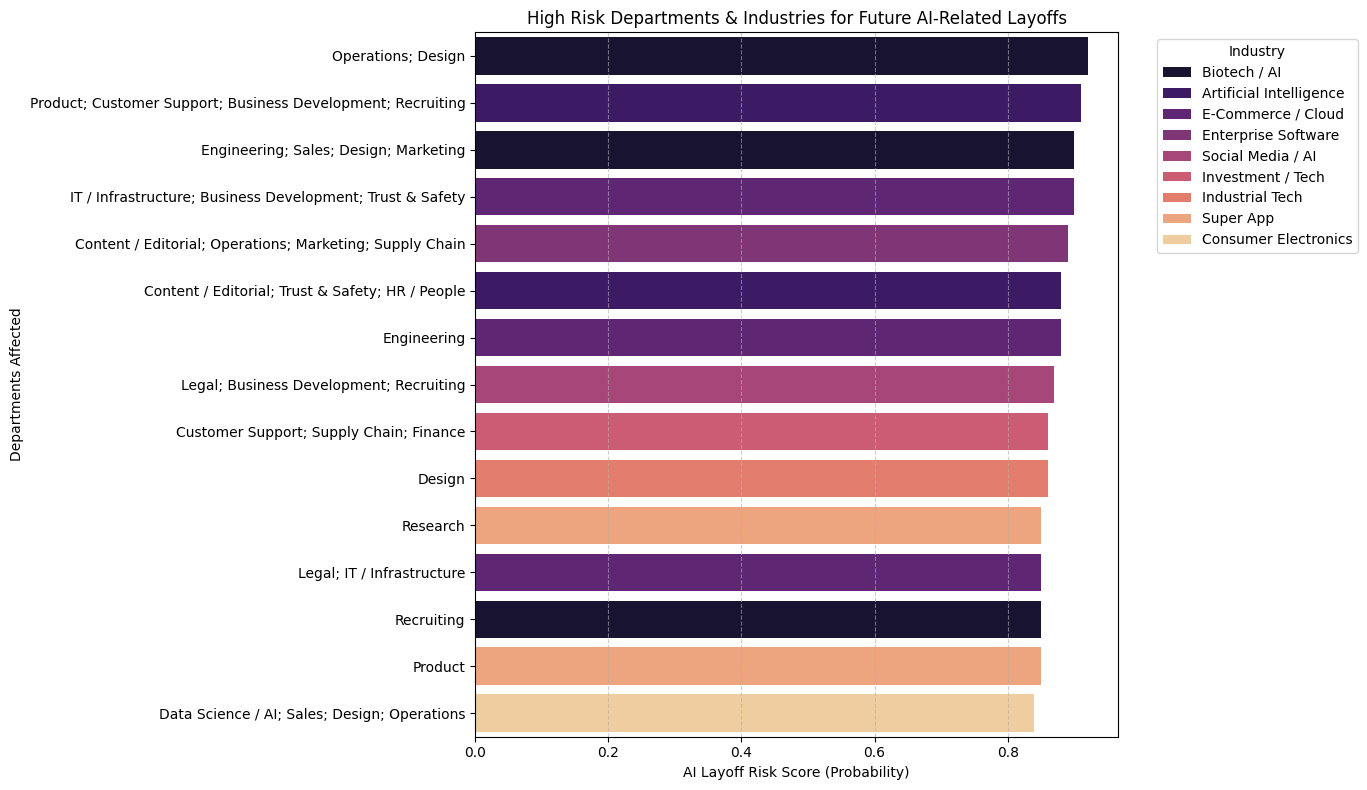

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train the refined model on the full refined dataset
model_pipeline_refined.fit(X_refined, y)

# 2. Get probability of AI-related layoffs for each entry
probabilities = model_pipeline_refined.predict_proba(X_refined)[:, 1]

# 3. Create an insight dataframe
insight_df = X_refined[['company', 'industry', 'departments_affected']].copy()
insight_df['ai_layoff_risk_score'] = probabilities

# 4. Group by Department and Company to find high-risk segments
# We'll look at the top 15 highest risk combinations
risk_summary = insight_df.groupby(['departments_affected', 'industry']).agg({
    'ai_layoff_risk_score': 'mean',
    'company': 'count'
}).rename(columns={'company': 'occurrence_count'}).reset_index()

risk_summary = risk_summary.sort_values(by='ai_layoff_risk_score', ascending=False).head(15)

# 5. Visualize the insights
plt.figure(figsize=(14, 8))
sns.barplot(data=risk_summary, x='ai_layoff_risk_score', y='departments_affected', hue='industry', palette='magma')
plt.title('High Risk Departments & Industries for Future AI-Related Layoffs')
plt.xlabel('AI Layoff Risk Score (Probability)')
plt.ylabel('Departments Affected')
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Key Takeaways:
- The **Risk Score** represents the model's confidence that a layoff in that specific department/industry combination is driven by AI.
- Departments with higher scores are those where the model has identified strong historical links to AI-driven restructuring.

Target column company , indrustry ,number_laid_off ,departments_affected  ,is_ai_related_layoff ,year